# Lecture 10 Correlation

---

## Outline

* [Prediction](#Prediction)
* [Association](#Association)
* [Correlation Coefficient](#Correlation-Coefficient)
* [Care in Interpretation](#Care-in-Interpretation)

## Set Up the Notebook

In [63]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Some functions for plotting. You are not required to understand how these work.
def resize_window(lim=3.5):
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='r'):
    y = x*slope + intercept
    plt.plot(x, y, color=color, lw=2)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plt.plot(x, y, color=color, lw=2)
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_scatter(r):
    """Generate a scatter plot with a correlation approximately r"""
    plt.figure(figsize=(5,5))
    x, y = make_correlated_data(r)
    plt.scatter(x, y, color='darkblue', s=20)
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    
def r_table(r):
    """
    Generate a table of 1000 data points with a correlation approximately r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

def nn_prediction_galton(h):
    """Return a prediction of the height of a child 
    whose parents have a midparent height of h.
    
    The prediction is the average height of the children 
    whose midparent height is in the range h plus or minus 0.5 inches.
    """
    neighbors = heights.where(
        'midparentHeight', are.between(h - 0.5, h + 0.5))
    return np.mean(neighbors.column('childHeight'))

In [64]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Functions defined in previous lectures

def standard_units(arr):
    """ Converts an array to standard units """
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates (predictions) at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

---

## Prediction
An important aspect of data science is to find out what data can tell us about the future. 

How can a patient’s medical history be used to judge how well he or she will respond to a treatment?


When we have two numerical variables x and y that are related to each other, we can use x to predict y.



### To predict the value of a variable

* Identify attribute that are associated with that variable and that you can measure
* Describe the relation between the attributes and the variable you want to predict
* Use the relation to make your prediction


---

### Demo: Prediction

## Approach to Prediction

In this section we will develop a measure of how tightly clustered a scatter diagram is about a straight line. Formally, this is called measuring linear association.

In [3]:
# Data on heights of parents and their adult children
families = Table.read_table('family_heights.csv')
families

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [4]:
parent_avgs = (families.column('father') + families.column('mother'))/2
parent_avgs

array([ 72.75,  72.75,  72.75,  72.75,  71.  ,  71.  ,  71.  ,  71.  ,
        69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  66.75,
        66.75,  66.75,  66.75,  66.75,  66.75,  71.  ,  71.  ,  71.  ,
        71.  ,  71.  ,  71.  ,  71.  ,  70.25,  70.25,  70.25,  70.25,
        69.75,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,
        68.  ,  67.5 ,  70.  ,  70.  ,  70.  ,  70.  ,  69.75,  69.75,
        69.75,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,
        69.  ,  69.  ,  68.75,  68.75,  68.75,  68.75,  68.75,  68.75,
        68.5 ,  68.5 ,  68.5 ,  68.1 ,  70.85,  70.85,  70.85,  70.85,
        70.85,  70.85,  70.85,  70.85,  70.  ,  70.  ,  70.  ,  69.5 ,
        69.5 ,  69.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,
        68.5 ,  68.75,  68.  ,  68.  ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,
        67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,
        67.5 ,  67.5 ,  68.  ,  68.  ,  68.  ,  67.  ,  67.25,  67.25,
      

In [5]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


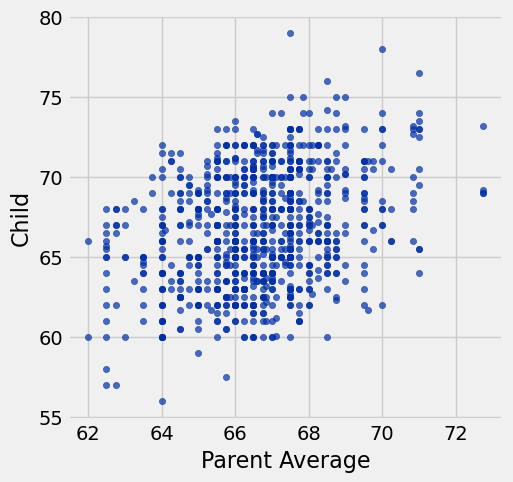

In [6]:
heights.scatter('Parent Average', 'Child')

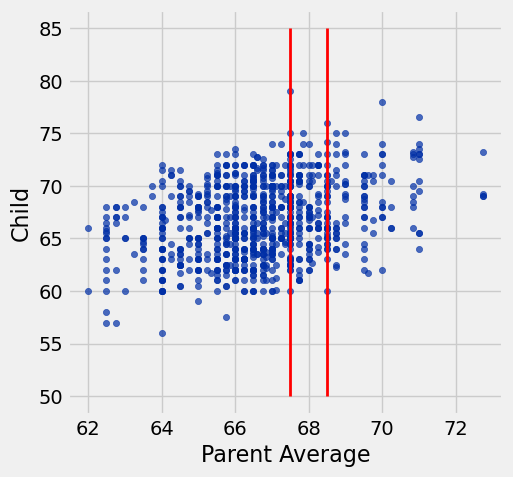

In [7]:
heights.scatter('Parent Average', 'Child')
plt.plot([67.5, 67.5], [50, 85], color='red', lw=2)

plt.plot([68.5, 68.5], [50, 85], color='red', lw=2);

In [8]:
nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

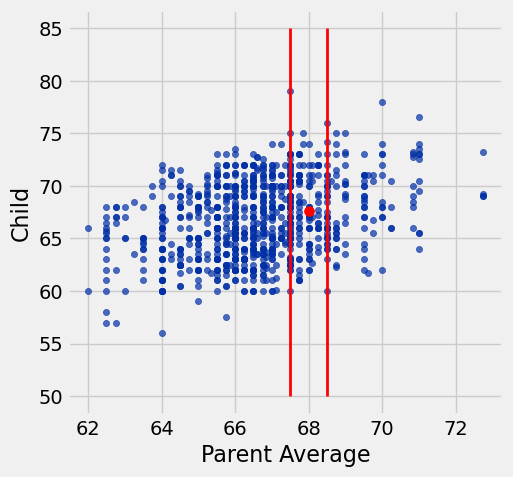

In [9]:
heights.scatter('Parent Average', 'Child')
plt.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plt.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plt.scatter(68, nearby_mean, color='red', s=50);

In [23]:
def predict_child(h):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    return np.average(nearby.column('Child'))

In [24]:
heights_with_predictions = heights.with_columns(
    'Prediction', heights.apply(predict_child, 'Parent Average'))

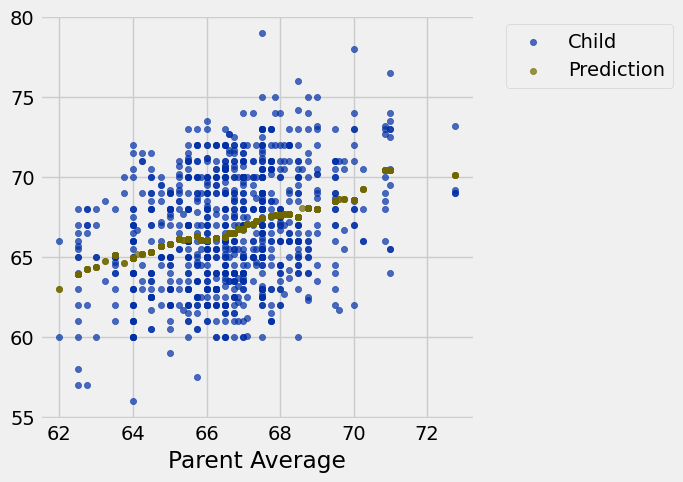

In [25]:
heights_with_predictions.scatter('Parent Average')

The prediction at a given midparent height lies roughly at the center of the vertical strip of points at the given height. 

This method of prediction is called `regression`.

## Measuring in Standard Units

Let’s see if we can find a way to identify this line. First, notice that linear association doesn’t depend on the units of measurement – we might as well measure both variables in standard units.

In [26]:
def standard_units(xyz):
    "Convert any array of numbers to standard units."
    return (xyz - np.mean(xyz))/np.std(xyz)  

In [28]:
heights_SU = Table().with_columns(
    'MidParent SU', standard_units(heights.column('Parent Average')),
    'Child SU', standard_units(heights.column('Child'))
)
heights_SU

MidParent SU,Child SU
3.51798,1.80416
3.51798,0.686005
3.51798,0.630097
3.51798,0.630097
2.50985,1.88802
2.50985,1.60848
2.50985,-0.348285
2.50985,-0.348285
1.64573,1.18917
1.64573,0.350559


In [29]:
sd_midparent = np.std(heights.column(0))
sd_midparent

1.7358819713866127

In [30]:
0.5/sd_midparent

0.28803801654821198

In [31]:
def predict_child_su(mpht_su):
    """Return a prediction of the height (in standard units) of a child 
    whose parents have a midparent height of mpht_su in standard units.
    """
    close = 0.5/sd_midparent
    close_points = heights_SU.where('MidParent SU', are.between(mpht_su-close, mpht_su + close))
    return close_points.column('Child SU').mean()   

In [32]:
heights_with_su_predictions = heights_SU.with_column(
    'Prediction SU', heights_SU.apply(predict_child_su, 'MidParent SU')
    )

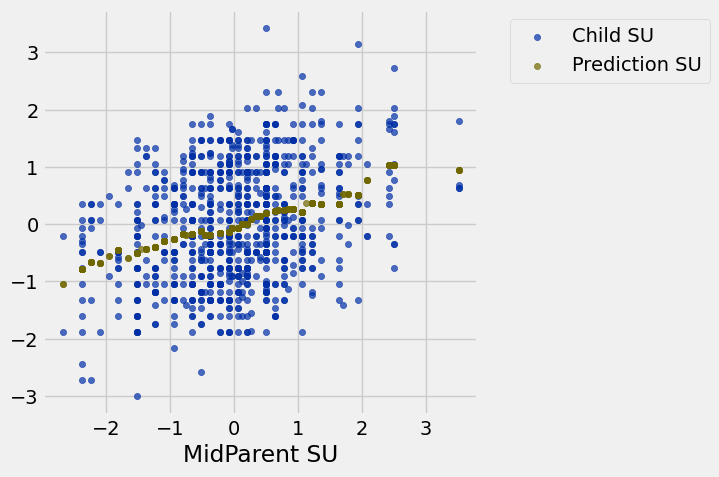

In [33]:
heights_with_su_predictions.scatter('MidParent SU')

---

## Association

---

### Two Numerical Variables


### Associations

Linear association is a measure of how tightly clustered a scatter diagram is about a straight line.

### Trend
Some general upward or downward movement.

* Positive association (A positive association means that as one variable increases, the other variable also tends to increase.)

* Negative association (A negative correlation, means that as one variable increases, the other variable tends to decrease.)

### Pattern
* Any discernible “shape” in the scatter
* Linear
* Non-linear

We can think of a positive association as having a positive, uptrending slope and a negative association as having a negative, downtrending slope; this does not necessarily mean that there needs to be a linear relation between the variables on the x- and y-axes.


---

Linear Association
The table hybrid contains data on hybrid passenger cars sold in the United States from 1997 to 2013. The data were adapted from the online data archive of Prof. Larry Winner of the University of Florida.

The columns:

vehicle: model of the car

year: year of manufacture

msrp: manufacturer’s suggested retail price in 2013 dollars

acceleration: acceleration rate in km per hour per second

mpg: fuel econonmy in miles per gallon

class: the model’s class.

Will develop a measure of how tightly clustered a scatter diagram is about a straight line.

Formally, this is called measuring linear association.

### Demo: Association

* Load the `hybrid.csv` data on several older hybrid cars.
* Visualize the relationship between several of the numerical variables.
* Use the `standard_units` function bellow to visualize the relationship between `mpg` and `msrp` in standard units.
* Use the `standard_units` function bellow to visualize the relationship between `acceleration` and `msrp` in standard units.

In [8]:
hybrid = Table.read_table('hybrid.csv')
hybrid

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact
Insight,2000,18936.4,9.52,53,Two Seater
Civic (1st Gen),2001,25833.4,7.04,47.04,Compact
Insight,2001,19036.7,9.52,53,Two Seater
Insight,2002,19137,9.71,53,Two Seater
Alphard,2003,38084.8,8.33,40.46,Minivan
Insight,2003,19137,9.52,53,Two Seater
Civic,2003,14071.9,8.62,41,Compact


In [18]:
hybrid.sort('msrp', descending=True)

vehicle,year,msrp,acceleration,mpg,class
Lexus LS600h/hL,2007,118544,17.54,21,Midsize
ActiveHybrid 7,2010,104300,20.41,22.11,Large
ActiveHybrid 7i,2011,102606,18.18,20,Midsize
ActiveHybrid X6,2009,97237.9,17.96,18.82,SUV
S400 Long,2009,96208.9,13.89,26.34,Large
Panamera S,2013,96150,18.52,25,Large
Panamera S,2012,95283.9,17.54,25,Large
S400,2013,92350,13.89,21,Large
S400,2010,88212.8,12.99,21,Large
ActiveHybrid 7L,2013,84300,18.18,25,Large


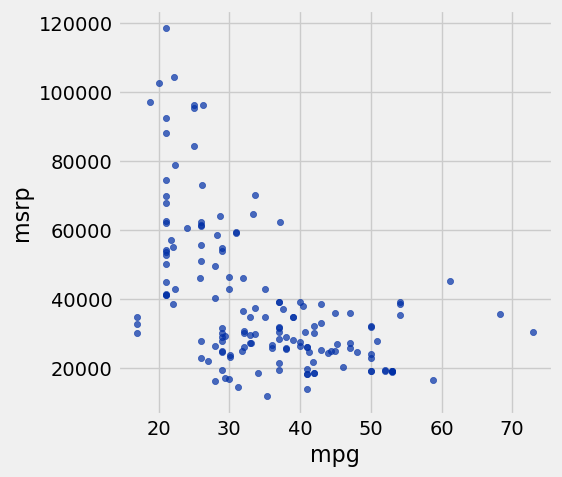

In [9]:
hybrid.scatter('mpg', 'msrp')

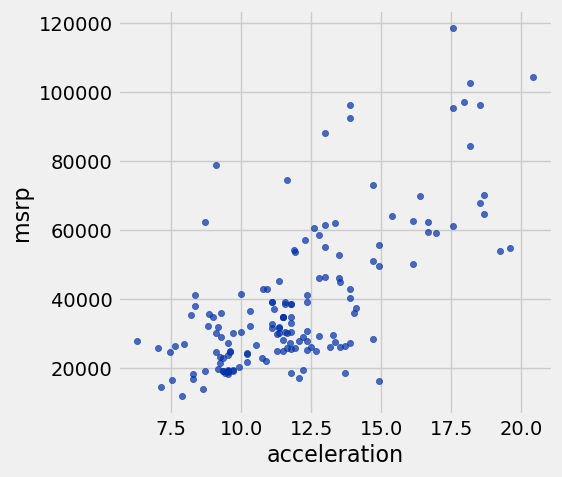

In [10]:
hybrid.scatter('acceleration', 'msrp')

Notice the `positive association.` 

* The scatter of points is sloping `upwards`, indicating that cars with greater acceleration tended to cost more, on average; 

* conversely, the cars that cost more tended to have greater acceleration on average.

If we restrict the data just to the SUV class, however, the association between price and efficiency is still negative but the relation appears to be more linear.

The relation between the price and acceleration of SUV’s also shows a linear trend, but with a positive slope.

In [11]:
suv = hybrid.where('class', 'SUV')
print(f'There are {suv.num_rows} SUVs in this dataset.')

There are 39 SUVs in this dataset.


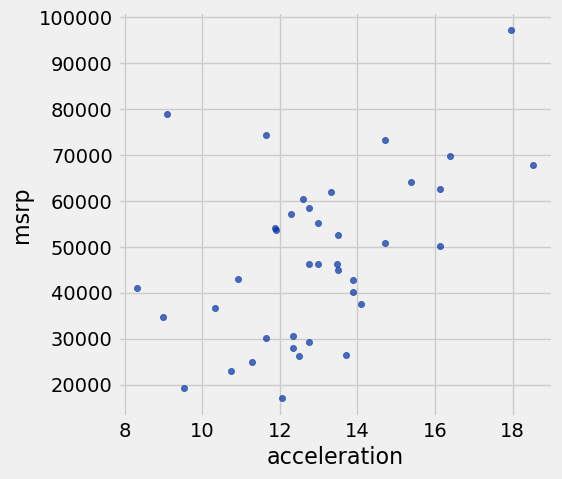

In [12]:
suv.scatter('acceleration', 'msrp')

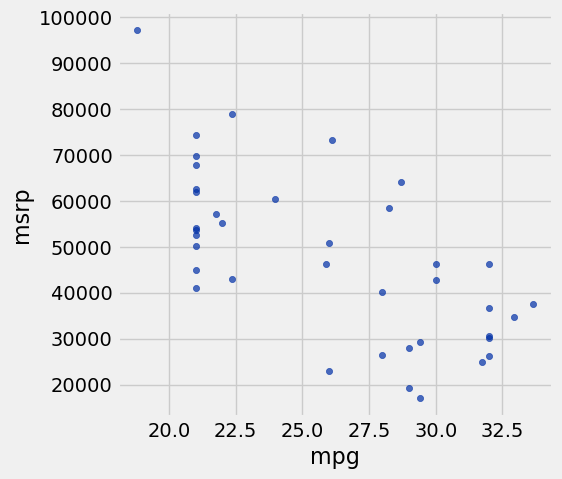

In [13]:
suv.scatter('mpg', 'msrp')

In [14]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

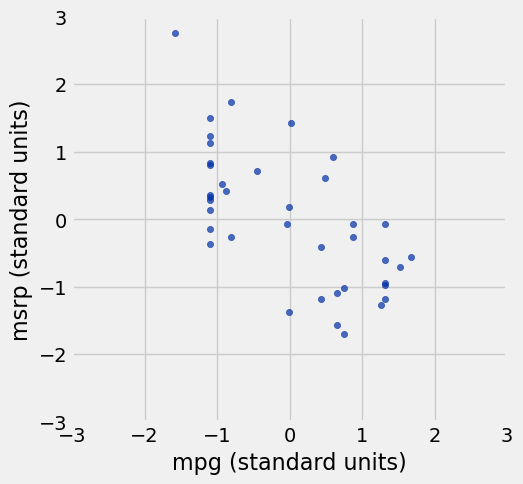

In [15]:
Table().with_columns(
    'mpg (standard units)',  standard_units(suv.column('mpg')), 
    'msrp (standard units)', standard_units(suv.column('msrp'))
).scatter(0, 1)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

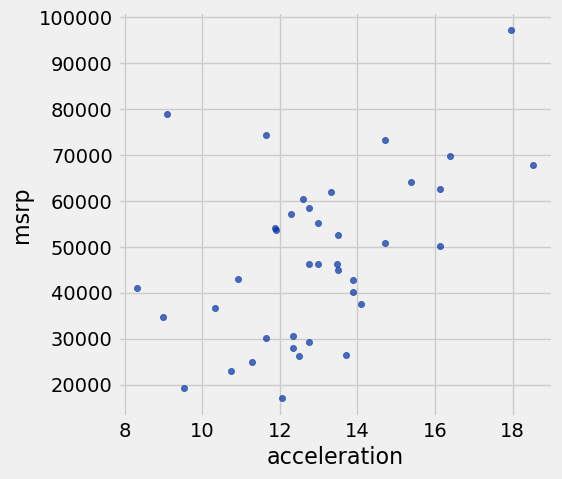

In [16]:
suv.scatter('acceleration', 'msrp')

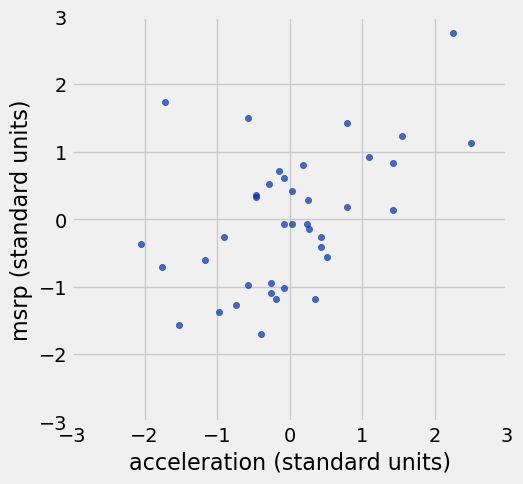

In [17]:
Table().with_columns(
    'acceleration (standard units)', standard_units(suv.column('acceleration')), 
    'msrp (standard units)',         standard_units(suv.column('msrp'))
).scatter(0, 1)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

In [18]:
suv_standardized = suv
for variable in ['msrp', 'acceleration', 'mpg']:
    standardized_variable = standard_units(suv.column(variable))
    suv_standardized = suv_standardized.with_column(variable, standardized_variable)
suv_standardized

vehicle,year,msrp,acceleration,mpg,class
Escape,2004,-0.60884,-1.16157,1.31784,SUV
Lexus RX400h,2005,0.605991,-0.0718039,0.48955,SUV
Highlander,2005,-1.02536,-0.0718039,0.747288,SUV
Escape 2WD,2005,-1.57389,-1.51888,0.659172,SUV
Mercury Mariner,2006,-0.714707,-1.76005,1.52491,SUV
Chevrolet Tahoe,2007,-0.261367,-0.898064,-0.805749,SUV
Kluger,2007,-0.0775641,-0.0718039,-0.0303321,SUV
Tribute,2007,-1.26796,-0.732812,1.26497,SUV
GMC Yukon,2007,0.526671,-0.286185,-0.931314,SUV
Vue,2007,-1.37281,-0.969524,-0.00169453,SUV


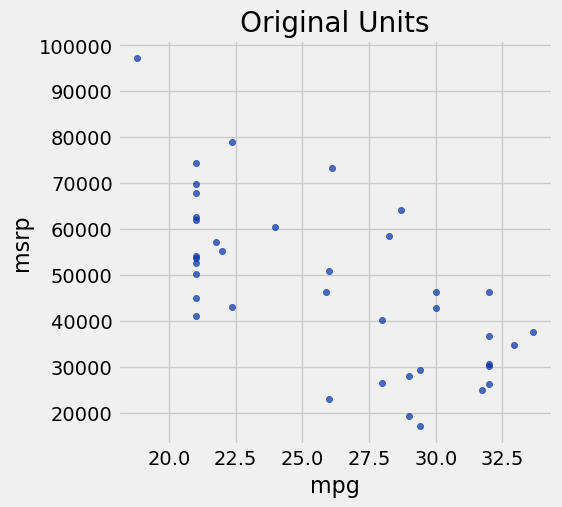

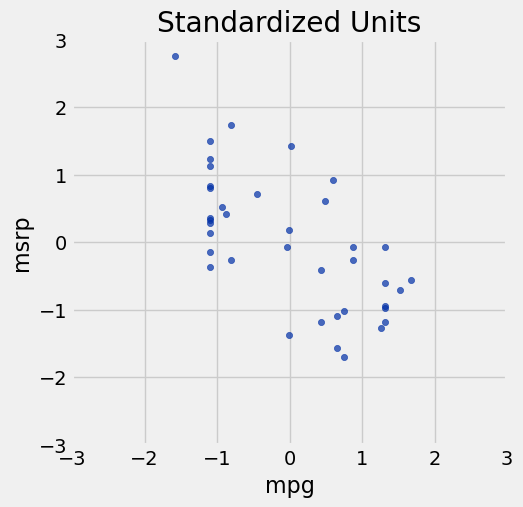

In [19]:
suv.scatter('mpg', 'msrp')
plt.title('Original Units')
suv_standardized.scatter('mpg', 'msrp')
plt.title('Standardized Units')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

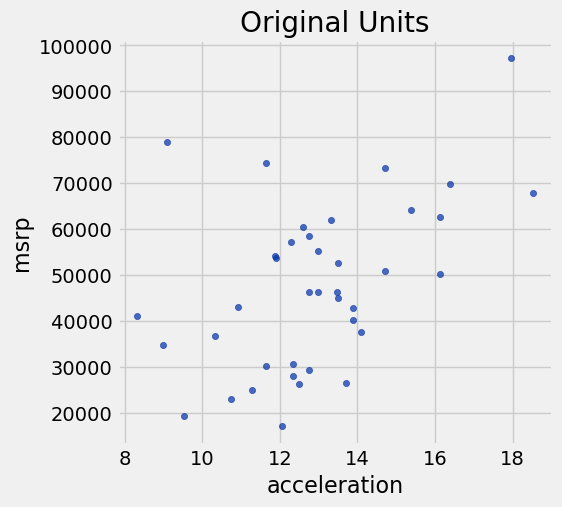

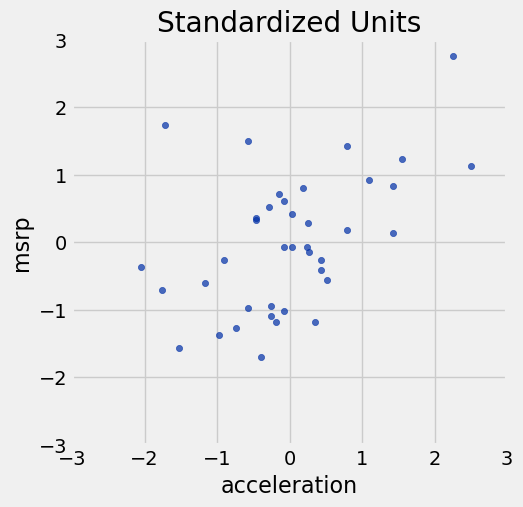

In [20]:
suv.scatter('acceleration', 'msrp')
plt.title('Original Units')
suv_standardized.scatter('acceleration', 'msrp')
plt.title('Standardized Units')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

---

## Correlation Coefficient

---

### The Correlation Coefficient

* Measures linear association
* Based on standard units
* $-1 \leq r \leq 1$
    * $r =  1$: scatter is perfect straight line sloping up
    * $r = -1$: scatter is perfect straight line sloping down
    * $r = 0$: No linear association; *uncorrelated*


---

### Definition of $r$

* Correlation Coefficient ($r$) = 
    * average of
    * product of
    * $x$ in standard units
    * and
    * $y$ in standard units
* Measures how clustered the scatter is around a straight line

---

### Examples of Scatterplots and $r$ values

<a href="https://en.wikipedia.org/wiki/Correlation"><img src="./correlation_examples.png" width = 80% alt="Several sets of (x, y) points, with the correlation coefficient of x and y for each set. The correlation reflects the noisiness and direction of a linear relationship (top row), but not the slope of that relationship (middle), nor many aspects of nonlinear relationships (bottom). N.B.: the figure in the center has a slope of 0 but in that case, the correlation coefficient is undefined because the variance of Y is zero." title="Correlation Examples"></a>

---

### Demo: Correlation

Demonstrate various scatter plots based on an inputted correlation coefficient using the `r_scatter` function.

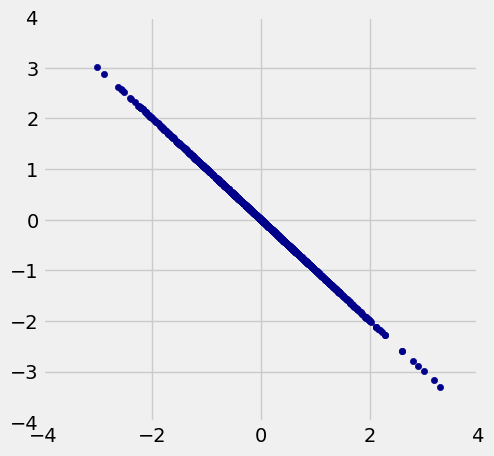

In [33]:
r_scatter(-1)

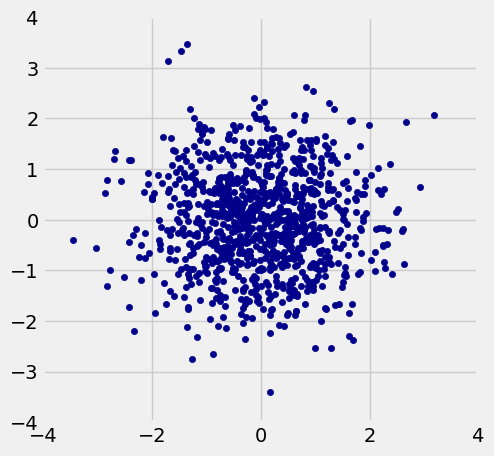

In [39]:
r_scatter(0)

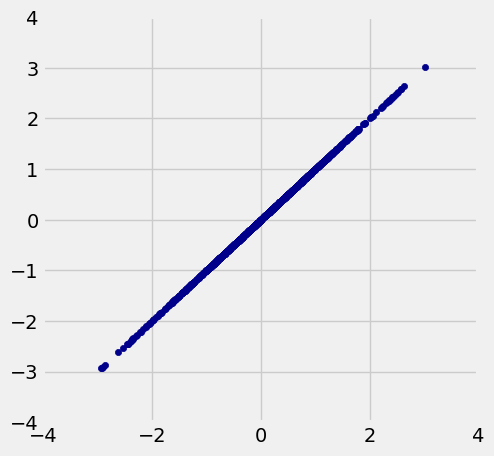

In [40]:
r_scatter(1)

---

### Demo: Calculating $r$

* Explore the concept of calculating the $r$ value. 
* Notice that $r$ is the average of the products of the standard units
* Define `correlation` as a function for a given table and x, y column labels.

In [42]:
x = np.arange(1, 7, 1)
y = make_array(2, 3, 1, 5, 2, 7)
t = Table().with_columns(
        'x', x,
        'y', y)
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


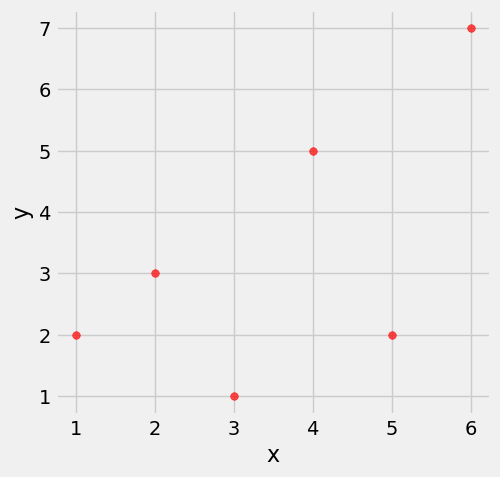

In [43]:
t.scatter('x', 'y', s=30, color='red')

In [46]:
def correlation(t, x, y):
    """t is a table; x and y are column labels"""
    x_in_standard_units = standard_units(t.column(x))
    y_in_standard_units = standard_units(t.column(y))
    return np.average(x_in_standard_units * y_in_standard_units)

In [47]:
correlation(t, 'x', 'y')

0.61741639718977093

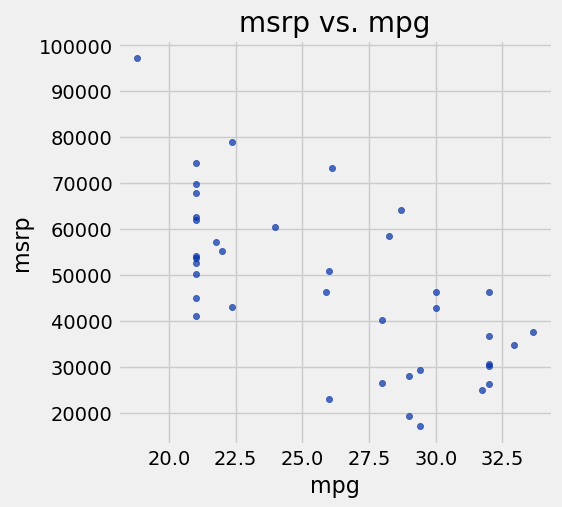

The correlation between these variables is -0.667


In [48]:
suv.scatter('mpg', 'msrp')
plt.title('msrp vs. mpg')
plt.show()
corr_mpg_msrp = correlation(suv, 'mpg', 'msrp')
print(f'The correlation between these variables is {corr_mpg_msrp: .3f}')

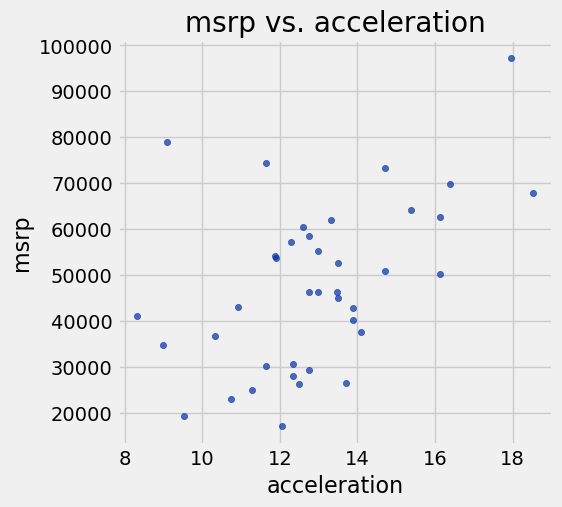

The correlation between these variables is  0.487


In [49]:
suv.scatter('acceleration', 'msrp')
plt.title('msrp vs. acceleration')
plt.show()
corr_accel_msrp = correlation(suv, 'acceleration', 'msrp')
print(f'The correlation between these variables is {corr_accel_msrp: .3f}')

---

### Demo: Switching Axes

Notice that `correlation(t, 'x', 'y') == correlation(t, 'y', 'x')`. This can lead to a false conclusion of causation.

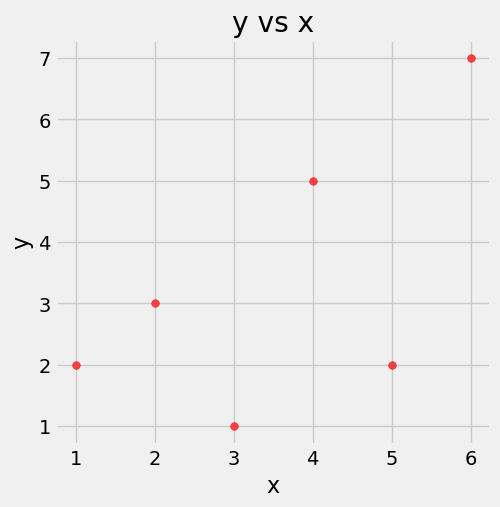

In [50]:
t.scatter('x', 'y', s=30, color='red')
plt.title('y vs x')
plt.show()

In [51]:
correlation(t, 'x', 'y')

0.61741639718977093

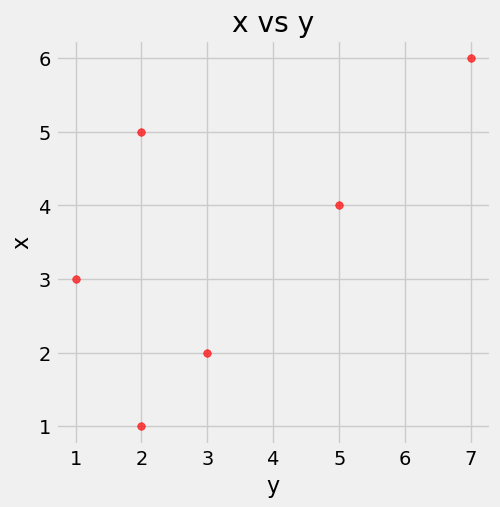

In [52]:
t.scatter('y', 'x', s=30, color='red')
plt.title('x vs y')
plt.show()

In [53]:
correlation(t, 'y', 'x')

0.61741639718977093

---

### Demo: Nonlinearity

Explore the correlation calculation for symmetrical non-linear data.

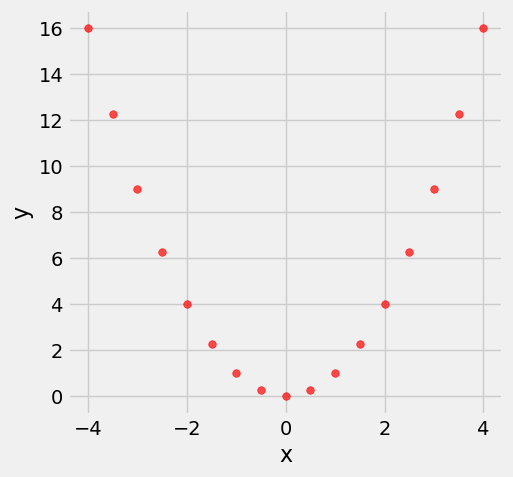

In [54]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
        'x', new_x,
        'y', new_x**2)
nonlinear.scatter('x', 'y', s=30, color='r')

In [55]:
correlation(nonlinear, 'x', 'y')

0.0

---

### Demo: Outliers

Notice how 1 outlier can strengthen or weaken an $r$ value depending on its value.

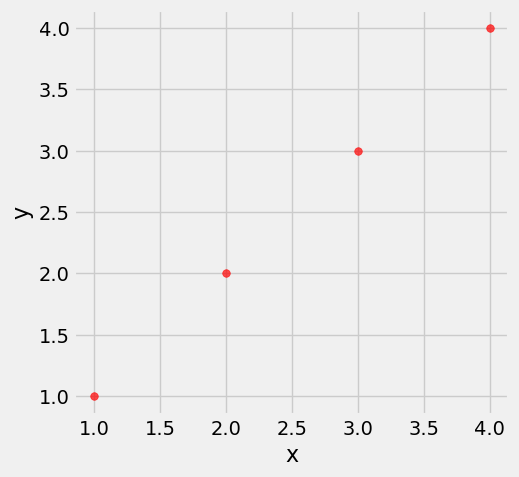

In [56]:
line = Table().with_columns(
        'x', make_array(1, 2, 3, 4),
        'y', make_array(1, 2, 3, 4))
line.scatter('x', 'y', s=30, color='r')

In [57]:
correlation(line, 'x', 'y')

1.0

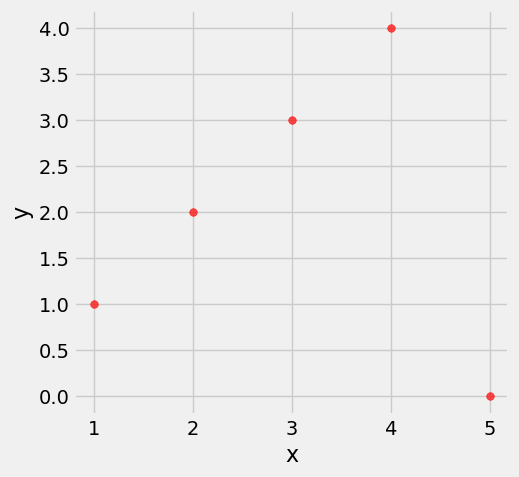

In [58]:
outlier = Table().with_columns(
        'x', make_array(1, 2, 3, 4, 5),
        'y', make_array(1, 2, 3, 4, 0)
    )
outlier.scatter('x', 'y', s=30, color='r')

In [59]:
correlation(outlier, 'x', 'y')

0.0

---

### Demo: Ecological Correlations

Explore an example of SAT scores (`sat2014.csv`) in connection to ecological correlations.

In [60]:
sat2014 = Table.read_table('sat2014.csv').sort('State')
sat2014

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547
Arkansas,4.2,573,571,554,1698
California,60.3,498,510,496,1504
Colorado,14.3,582,586,567,1735
Connecticut,88.4,507,510,508,1525
Delaware,100,456,459,444,1359
District of Columbia,100,440,438,431,1309
Florida,72.2,491,485,472,1448


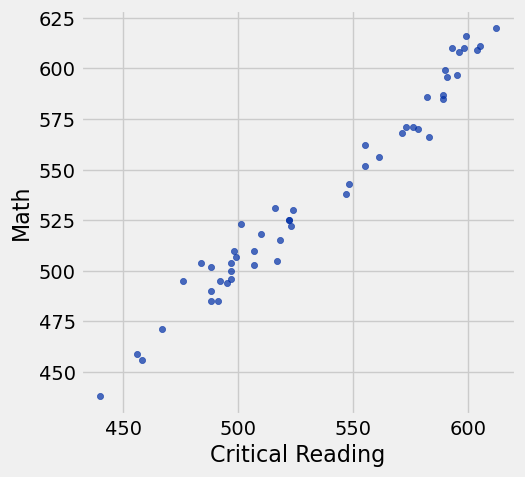

In [61]:
sat2014.scatter('Critical Reading', 'Math')

In [62]:
correlation(sat2014, 'Critical Reading', 'Math')

0.98475584110674341

* The correlation between aggregated data (e.g., after grouping) may be much higher than the correlation between the underlying variables.
* The correlation between these scores at the state level does not translate to the same correlation between the variables at the individual level.
* You may see a linear pattern in your data, but you need to consider the factors contributing to the formation of that line.

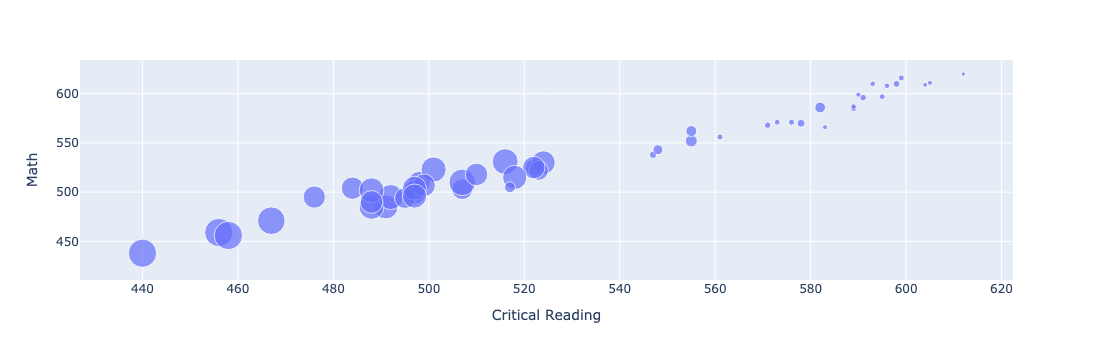

In [63]:
import plotly.express as px

px.scatter(sat2014.to_df(), x = 'Critical Reading', y = 'Math', 
           hover_name = 'State', size = 'Participation Rate')

---

### Final words on correlation

* Correlation only measures association. It does not imply causation.
* Correlation measures only one kind of association – linear. Variables that have a strong non-linear association might have very low correlation.
* Outliers can have a big effect on correlation
* We should be careful with correlations based on aggregates (ecological correlations)

# Linear Regression

---

## Outline

* [Prediction](#Prediction)
* [Linear Regression](#Linear-Regression)
* [Slope & Intercept](#Slope-&-Intercept)

---

## Prediction

---

### Nearest Neighbor Regression

* A method for prediction:
    * Group each x with similar (nearby) x values
    * Average the corresponding y values for each group
    * For each x value, the prediction is the average of the y values in its nearby group.
* The graph of these predictions is the "graph of averages".
* If the association between x and y is linear, then points in the graph of averages tend to fall on a line.


---

### Where is the prediction line? (`r=0.99`)


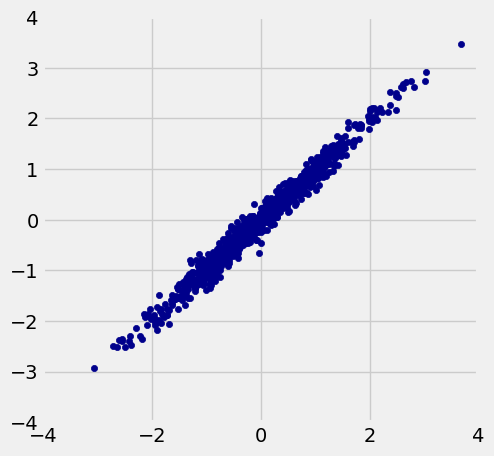

In [66]:
r_scatter(0.99)

---

### Where is the prediction line? (`r=0`)


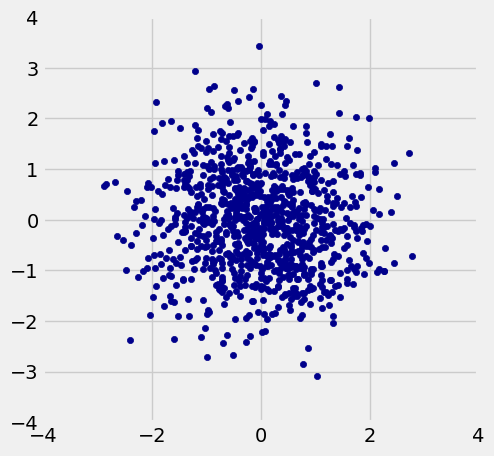

In [67]:
r_scatter(0)

---

### Demo: Prediction lines `r = 0.99`

Identify the best fit line in relation to the nearest neighbor predictions with data showing an r value of 0.99.

In [68]:
example = r_table(0.99)
example.show(3)

x,y
0.0912047,-0.0680119
1.09128,1.04391
-1.94697,-1.88316


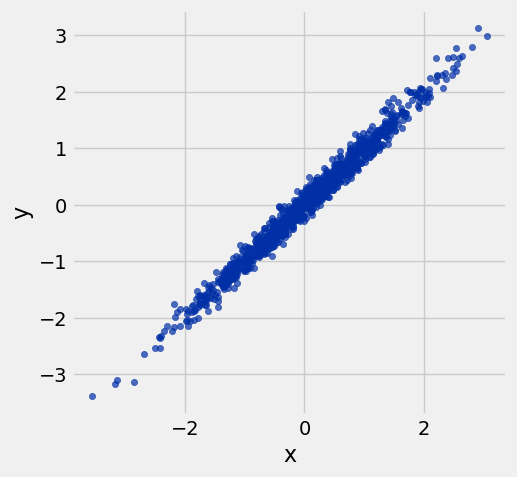

In [69]:
example.scatter('x', 'y')

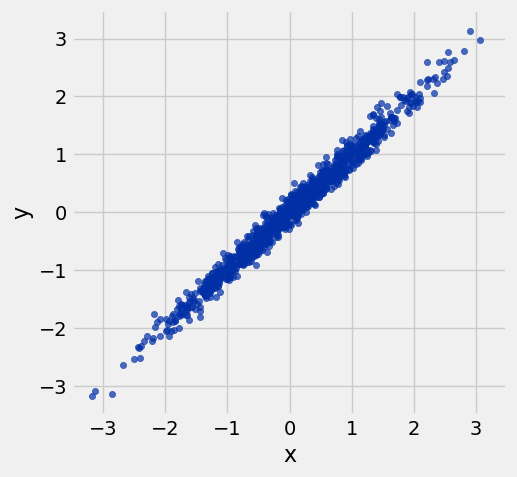

In [70]:
example.scatter('x', 'y')
resize_window()

In [71]:
def nn_prediction_example(x_val):
    """ Predicts y-value for x based on the example table """
    neighbors = example.where('x', are.between(x_val - .25, x_val + .25))
    return np.mean(neighbors.column('y'))
    

In [72]:
nn_prediction_example(-2.25)

-2.1476337989800522

In [73]:
example = example.with_columns(
    'Predicted y', 
    example.apply(nn_prediction_example, 'x'))

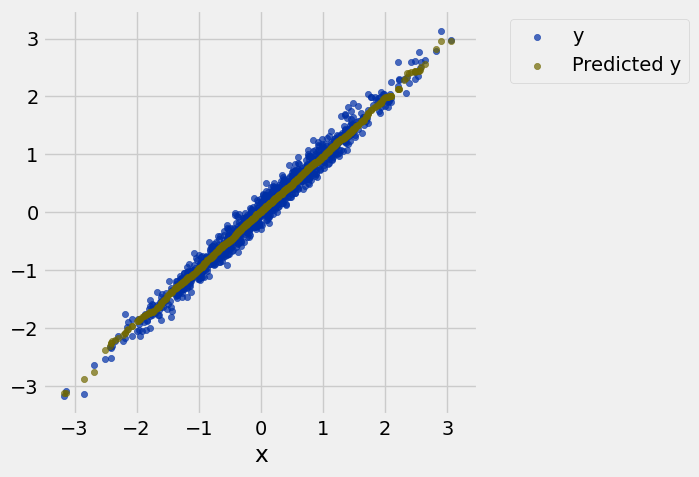

In [74]:
example.scatter('x')
resize_window()

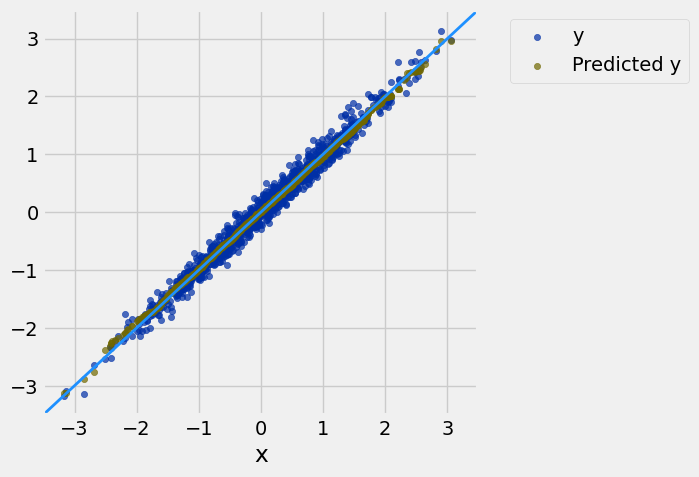

In [75]:
example.scatter('x')
draw_line(slope=1, color='dodgerblue')
resize_window()

### Demo: Prediction lines `r = 0`

Identify the best fit line in relation to the nearest neighbor predictions with data showing an r value of 0.

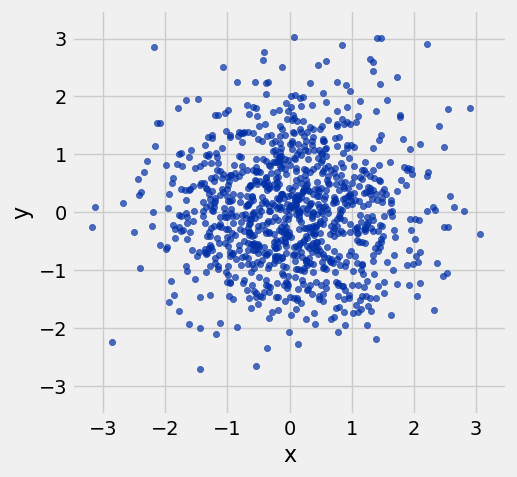

In [76]:
example = r_table(0)
example.scatter('x', 'y')
resize_window()

In [77]:
example = example.with_columns(
    'Predicted y', 
    example.apply(nn_prediction_example, 'x'))

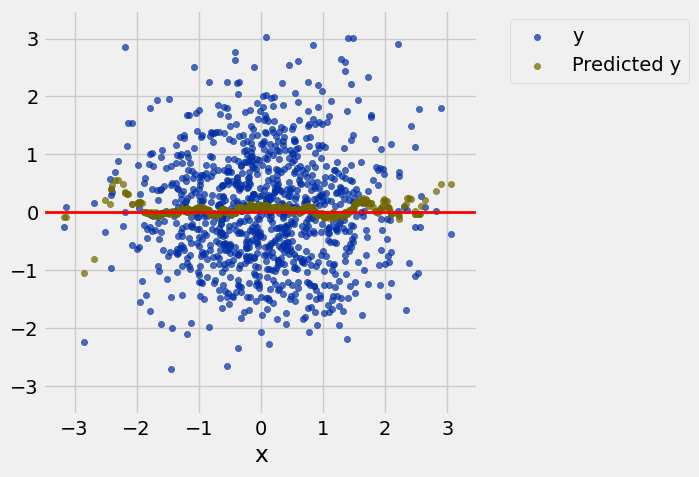

In [78]:
example = example.with_column(
    'Predicted y', example.apply(nn_prediction_example, 'x'))
example.scatter('x')
draw_line(slope = 0)
resize_window()

### Demo: Prediction lines `r = 0.5`

Identify the best fit line in relation to the nearest neighbor predictions with data showing an r value of 0.5.

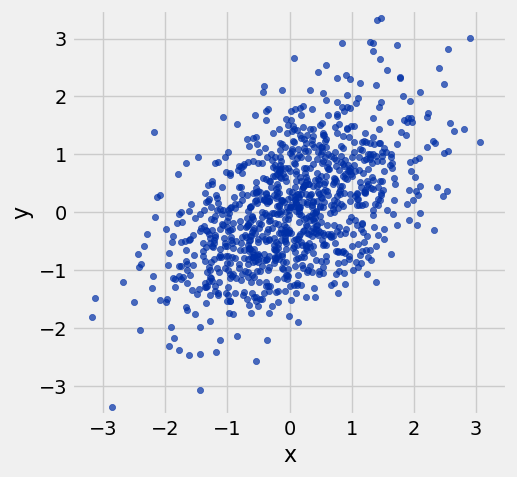

In [79]:
example = r_table(0.5)
example.scatter('x', 'y')
resize_window()

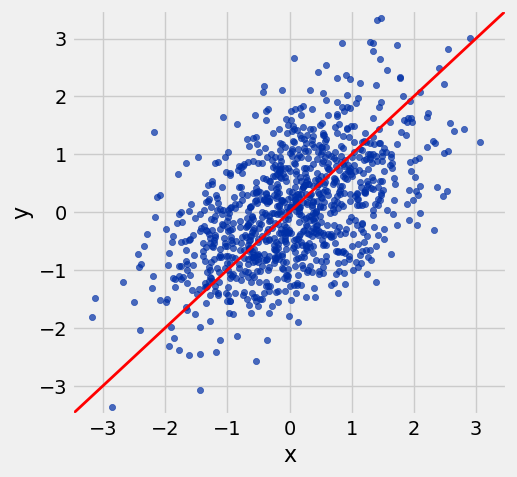

In [80]:
example = r_table(0.5)
example.scatter('x', 'y')
resize_window()
draw_line(slope=1, intercept=0)

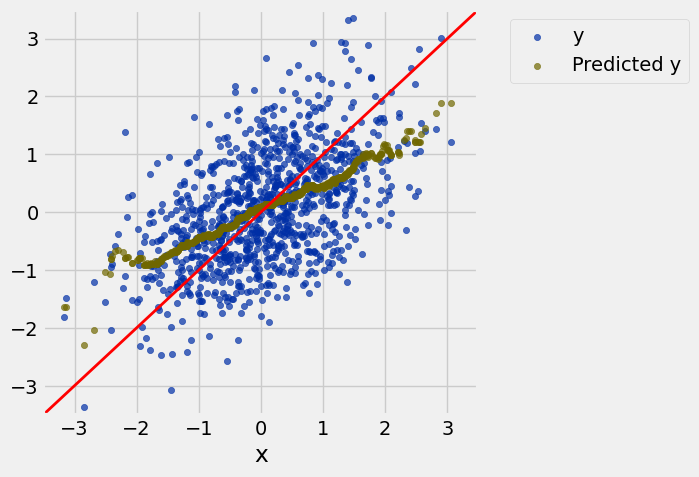

In [81]:
example = example.with_column('Predicted y', example.apply(nn_prediction_example, 'x'))
example.scatter('x')
draw_line(slope=1)
resize_window()

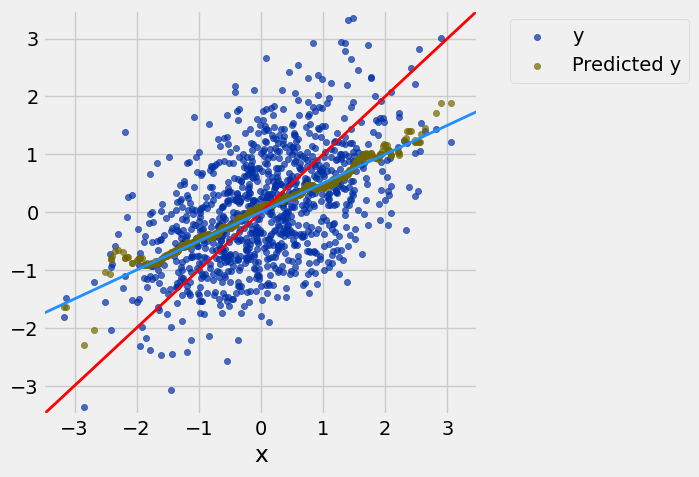

In [82]:
example.scatter('x')
draw_line(slope=1, intercept=0, color='red')
draw_line(slope=0.5, intercept=0, color='dodgerblue')
resize_window()

---

## Linear Regression

---

### Linear Regression

* A statement about x and y pairs
    * Measured in standard units
    * Describing the deviation of $x$ from 0 (the average of $x$'s)
    * And the deviation of $y$ from 0 (the average of $y$'s)
* On average, $y$ deviates from 0 less than $x$ deviates from 0
* Regression Line Equation: $y_{\text{su}} = r \times x_{\text{su}}$
* Not true for all points — a statement about averages

---

## Slope & Intercept

---

### Regression Line Equation

* In original units, the regression line has this equation: $$\frac{\text{estimate of } y - \text{average of } y}{\text{SD of } y} = r \times \frac{\text{the given } x - \text{average of } x}{\text{SD of } x}$$
* Lines can be expressed by slope & intercept as: $y = \text{slope} \times x + \text{intercept}$

---

### Regression Line

<img src="./regression_line.png" width=60%>

---

### Slope and Intercept

* `estimate_of_y = slope * x + intercept`
* `slope = r * (SD_y / SD_x)`
* `intercept = mean_y - slope * mean_x`

---

### Demo: Defining the line

Use the `standard_units` and `correlation` functions (copied from above) to define functions `slope` and `intercept`. 

In [85]:
example = r_table(0.5)
slope(example, 'x', 'y'), intercept(example, 'x', 'y')

(0.50226382816259152, 0.038014795445425811)

---

### Units

Suppose we use linear regression to predict candy prices (in dollars) from sugar content (in grams). The units of the following are:

* $r$ - no units
* The slope - dollars/grams
* The intercept - dollars

Predicting Heights
How can we predict child height from the parents’average height?

How to predict a child's height, given a midparent height 68 inches?

Use the average height of the children of all families in which the midparent height is close to 68 inches

In [35]:
# Note: Child heights are the **adult** heights of children in a family
families = Table.read_table('family_heights.csv')


parent_avgs = (families.column('father') + families.column('mother'))/2
parent_avgs 

array([ 72.75,  72.75,  72.75,  72.75,  71.  ,  71.  ,  71.  ,  71.  ,
        69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  69.5 ,  66.75,
        66.75,  66.75,  66.75,  66.75,  66.75,  71.  ,  71.  ,  71.  ,
        71.  ,  71.  ,  71.  ,  71.  ,  70.25,  70.25,  70.25,  70.25,
        69.75,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,  68.  ,
        68.  ,  67.5 ,  70.  ,  70.  ,  70.  ,  70.  ,  69.75,  69.75,
        69.75,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,  69.  ,
        69.  ,  69.  ,  68.75,  68.75,  68.75,  68.75,  68.75,  68.75,
        68.5 ,  68.5 ,  68.5 ,  68.1 ,  70.85,  70.85,  70.85,  70.85,
        70.85,  70.85,  70.85,  70.85,  70.  ,  70.  ,  70.  ,  69.5 ,
        69.5 ,  69.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,  68.5 ,
        68.5 ,  68.75,  68.  ,  68.  ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,
        67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,  67.5 ,
        67.5 ,  67.5 ,  68.  ,  68.  ,  68.  ,  67.  ,  67.25,  67.25,
      

In [36]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
)
heights.show(5)

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5


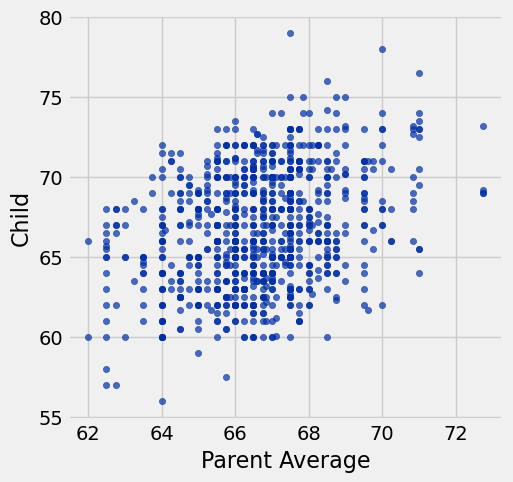

In [37]:
heights.scatter('Parent Average')

### Nearest Neighbor Regression

A method for prediction:

* Group each x with similar (nearby) x values
* Average the corresponding y values for each group

For each x value, the prediction is the average of the y
values in its nearby group.

### Graph of averages

The graph of these predictions is the `“graph of averages”`.

If the association between x and y is linear, then points in
the graph of averages tend to fall on a line. That is a `Regression Line`.

In [38]:
def nn_prediction_height(p_avg):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    
    close_points = heights.where('Parent Average', are.between(p_avg-0.5, p_avg + 0.5))
    return np.average(close_points.column('Child')) 

In [39]:
heights_with_predictions = heights.with_column(
    'Nearest neighbor prediction', 
    heights.apply(nn_prediction_height, 'Parent Average'))
heights_with_predictions.show(5)

Parent Average,Child,Nearest neighbor prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158


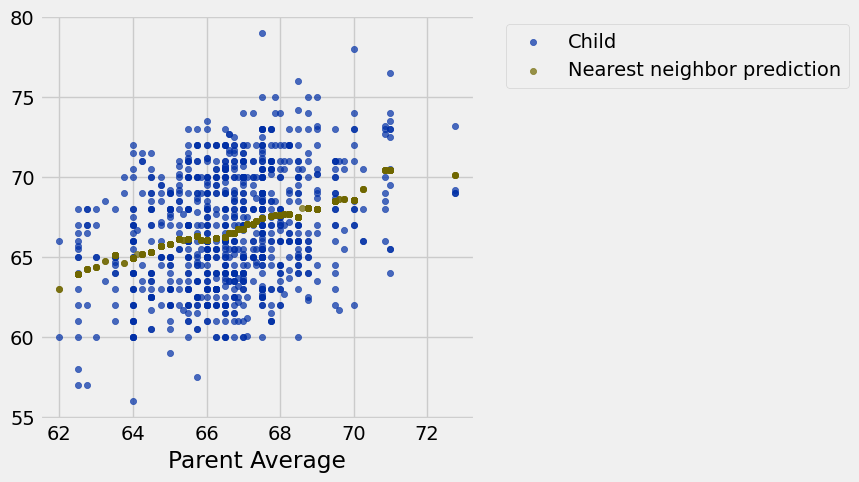

In [92]:
heights_with_predictions.scatter('Parent Average')

In [42]:
predicted_heights_slope = slope(heights, 'Parent Average', 'Child')
predicted_heights_intercept = intercept(heights, 'Parent Average', 'Child')
[predicted_heights_slope, predicted_heights_intercept]

[0.66449526235258838, 22.461839955758798]

In [43]:
heights_with_predictions = heights_with_predictions.with_column(
    'Regression Prediction', 
    predicted_heights_slope*heights.column('Parent Average') + predicted_heights_intercept
)
heights_with_predictions

Parent Average,Child,Nearest neighbor prediction,Regression Prediction
72.75,73.2,70.1,70.8039
72.75,69.2,70.1,70.8039
72.75,69,70.1,70.8039
72.75,69,70.1,70.8039
71,73.5,70.4158,69.641
71,72.5,70.4158,69.641
71,65.5,70.4158,69.641
71,65.5,70.4158,69.641
69.5,71,68.5025,68.6443
69.5,68,68.5025,68.6443


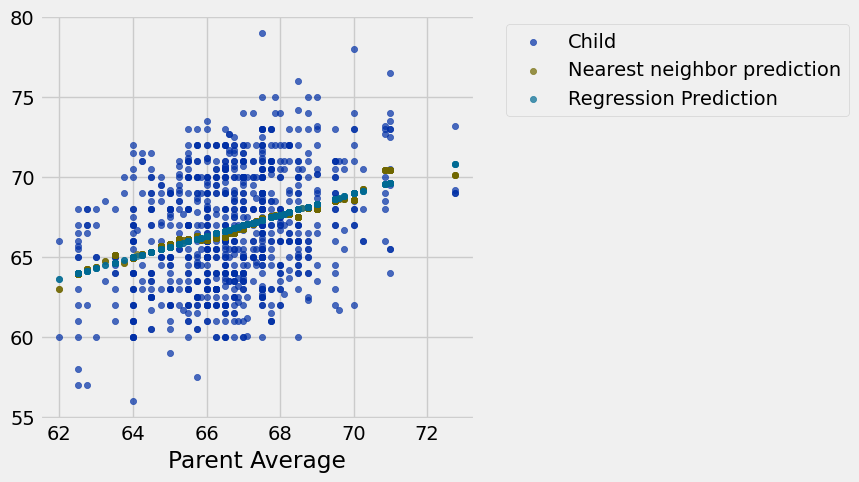

In [44]:
heights_with_predictions.scatter('Parent Average')

---

# Least Squares

## Outline

* [Least Squares](#Least-Squares)
* [Numerical Optimization](#Numerical-Optimization)
* [Nonlinear Regression](#Nonlinear-Regression)

## Least Squares

---

### Interpreting a Relationship

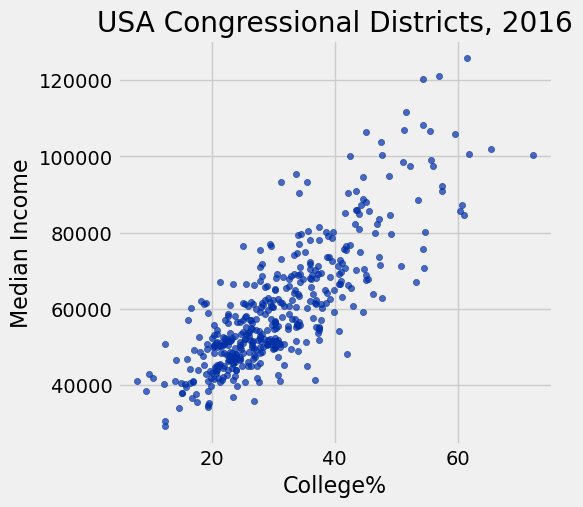

In [66]:
demographics = Table().read_table('district_demographics2016.csv')
demographics.scatter('College%', 'Median Income')
plt.title('USA Congressional Districts, 2016')
plt.show()

In [67]:
demographics

State,District,Median Income,College%
Alabama,"Congressional District 1 (115th Congress), Alabama",47083,24
Alabama,"Congressional District 2 (115th Congress), Alabama",42035,21.8
Alabama,"Congressional District 3 (115th Congress), Alabama",46544,22.8
Alabama,"Congressional District 4 (115th Congress), Alabama",41110,17
Alabama,"Congressional District 5 (115th Congress), Alabama",51690,30.3
Alabama,"Congressional District 6 (115th Congress), Alabama",61413,36.7
Alabama,"Congressional District 7 (115th Congress), Alabama",34664,19.4
Alaska,"Congressional District (at Large) (115th Congress), Alaska",76440,29.6
Arizona,"Congressional District 1 (115th Congress), Arizona",50537,24.5
Arizona,"Congressional District 2 (115th Congress), Arizona",49072,34


Based only on the above graph, which must be true?
1. Going to college causes people to get higher incomes.
2. For any district, having more college-educated people live there causes median incomes to rise.
3. For any district, having a higher median income causes more college-educated people to move there.

---

### Error in Estimation

* `error = actual value - estimate`
* Typically, some errors are positive and some negative
* A way to measure the rough size of the errors:
    * square the errors to eliminate cancellation
    * take the mean of the squared errors
    * take the square root to fix the units
* This is called the root mean square error (rmse)

---

The following statements are the ordered steps of linear regression.
Determine if linear regression is a reasonable method by visualizing your data and computing the correlation coefficient.
Compute the parameters of the regression line: the slope and the intercept.
Use the regression line to generate predictions for each x value.
Evaluate the regression line by computing the line’s RMSE (Root Mean Squared Error)and analyzing the residuals plot.

---

### Least Squares Line

* Minimizes the root mean squared error (rmse) among all lines
* Equivalently, minimizes the mean squared error (mse) among all lines
* Common Names:
    * "Best fit" line
    * Least squares line
    * Regression line


---

## Numerical Optimization

---

### Numerical Optimization

* Numerical minimization is approximate but effective
* Lots of machine learning uses numerical minimization
* If the function `mse(a, b)` returns the mse of estimation using the line `estimate = ax + b`, then `minimize(mse)` returns array `[slope, intercept]`
* the values are the slope and the intercept of the line that minimizes the mse among all possible lines.

---

### Demo: Numerical Optimization

Explore the concept of numerical optimization.

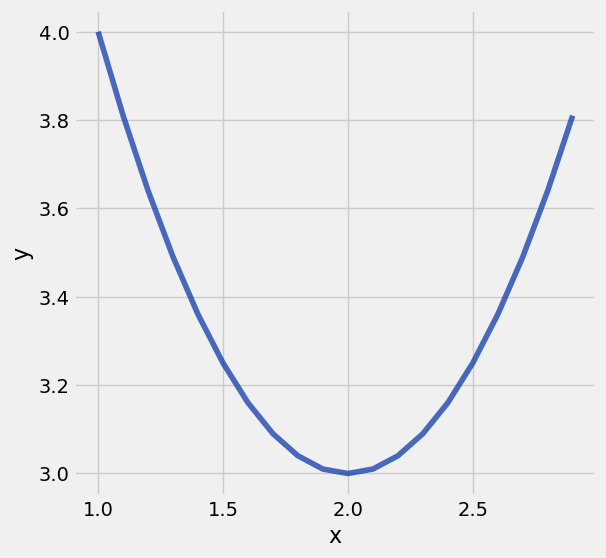

In [46]:
x = np.arange(1, 3, 0.1)
y = (x-2)**2 + 3
Table().with_columns('x', x, 'y', y).plot('x')

In [47]:
def f(x):
    return ((x-2)**2) + 3

In [49]:
f(2)

3

In [ ]:
x = np.arange(-1.5, 1.5, 0.05)
y2 = 2 * np.sin(x*np.pi) + x ** 3 + x ** 4 
Table().with_columns('x', x, 'y', y2).plot('x')

In [51]:
def complicated_function(x):
    return 2 * np.sin(x*np.pi) + x ** 3 + x ** 4 

In [52]:
complicated_function(3)

108.0

---

### Demo: Minimizing RMSE

Show how minimizing on the demographics rmse produces the same slope and intercept values found above. 

In [53]:
def demographics_rmse(any_slope, any_intercept):
    x = demographics.column('College%')
    y = demographics.column('Median Income')
    estimate = any_slope*x + any_intercept
    return (np.mean((y - estimate) ** 2)) ** 0.5

In [54]:
demographics_rmse(1500, 20000)

11559.086490075999

In [55]:
demographics_rmse(-1000, 75000)

30247.883767944502

---

## Nonlinear Regression

---

### Demo: Trying Linear Regression

In [57]:
shotput = Table.read_table('shotput.csv')
shotput

Weight Lifted,Shot Put Distance
37.5,6.4
51.5,10.2
61.3,12.4
61.3,13
63.6,13.2
66.1,13
70,12.7
92.7,13.9
90.5,15.5
90.5,15.8


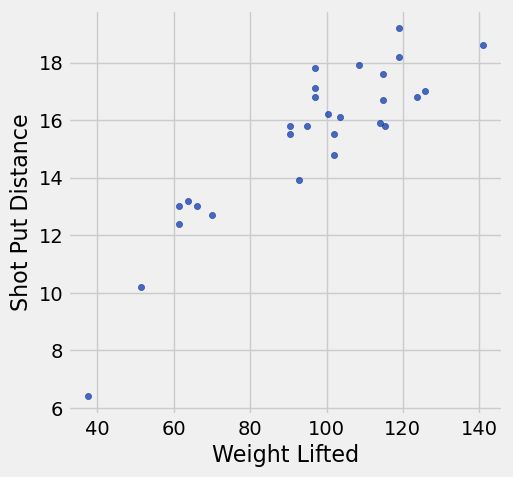

In [58]:
shotput.scatter('Weight Lifted')

In [69]:
slope(shotput, 'Weight Lifted', 'Shot Put Distance')

0.098343821597819972

In [70]:
intercept(shotput, 'Weight Lifted', 'Shot Put Distance')

5.9596290983739522

In [71]:
def shotput_linear_mse(any_slope, any_intercept):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    fitted = any_slope*x + any_intercept
    return np.mean((y - fitted) ** 2)

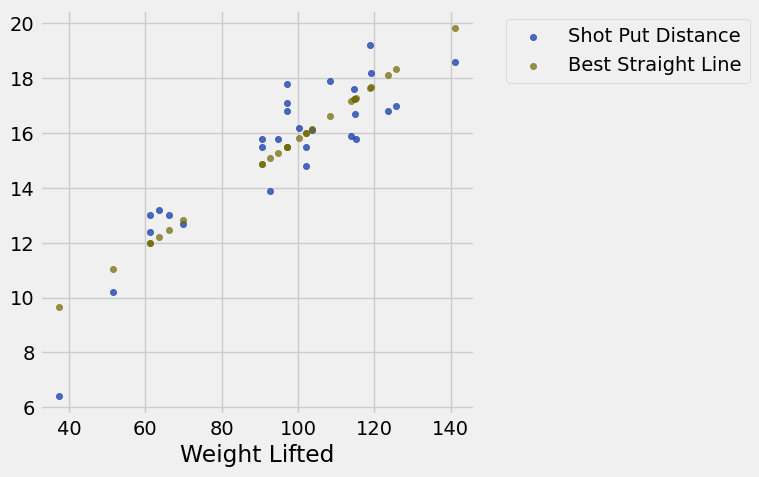

In [73]:
fitted = fitted_values(shotput, 'Weight Lifted', 'Shot Put Distance')
shotput.with_column('Best Straight Line', fitted).scatter('Weight Lifted')

In [75]:
weights = shotput.column(0)

### Demo: Nonlinear Regression

Try using a quadratic model instead.
* Quadratic models are nonlinear models.
* The generic structure for a quadratic model is:
$$
f(x) ~=~ ax^2 + bx + c
$$
for constants $a$, $b$, and $c$.

In [111]:
shotput = Table.read_table('shotput.csv')
shotput

Weight Lifted,Shot Put Distance
37.5,6.4
51.5,10.2
61.3,12.4
61.3,13
63.6,13.2
66.1,13
70,12.7
92.7,13.9
90.5,15.5
90.5,15.8


In [ ]:
shotput.scatter('Weight Lifted')

In [114]:
def shotput_linear_rmse(any_slope, any_intercept):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    estimate = any_slope*x + any_intercept
    return np.mean((y - estimate) ** 2) ** 0.5

In [115]:
best_line = minimize(shotput_linear_rmse)
best_line

array([ 0.09834382,  5.95962883])

In [116]:
weights = shotput.column(0)

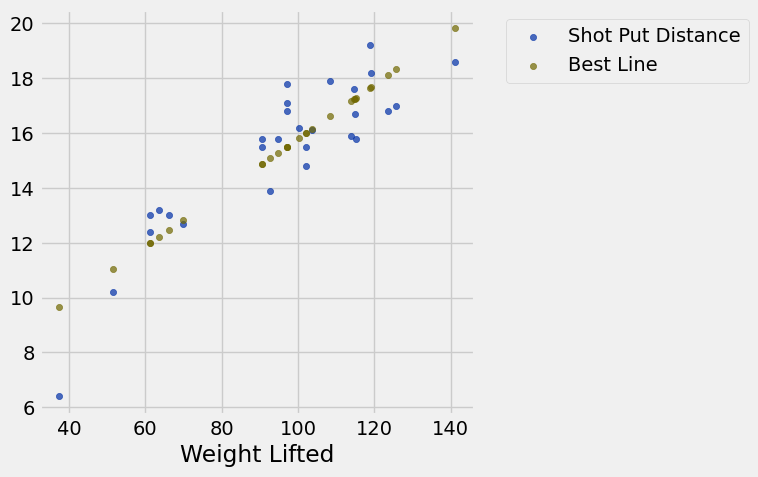

In [117]:
linear_fit = best_line.item(0)*weights + best_line.item(1)

shotput.with_column(
    'Best Line', linear_fit
).scatter(0)

### Quadratic Function

In [76]:
def shotput_quadratic_mse(a, b, c):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    fitted = a*(x**2) + b*x + c
    return np.mean((y - fitted) ** 2)

In [77]:
best = minimize(shotput_quadratic_mse)
best

array([ -1.04004838e-03,   2.82708045e-01,  -1.53182115e+00])

In [79]:
# x = weight lifted = 100 kg
# Then predicted shot put distance:
a = best.item(0)
b = best.item(1)
c = best.item(2)

prediction_for_100kg = a * (100 ** 2) + b * 100 + c
prediction_for_100kg

16.338499489970285

In [80]:
x = shotput.column(0)
shotput_fit = best.item(0)*(x**2) + best.item(1)*x + best.item(2)

In [ ]:
shotput_quad = shotput.with_column('Best Quadratic Curve', quad_fit)
shotput_quad.scatter('Weight Lifted')

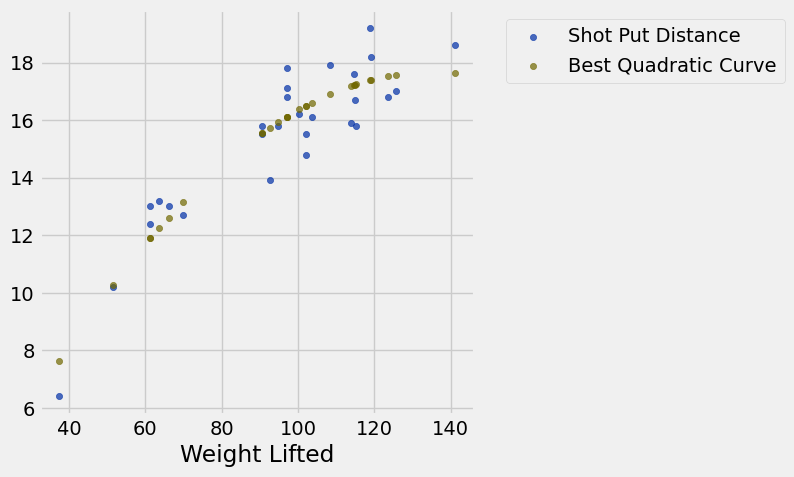

In [81]:
shotput.with_column('Best Quadratic Curve', shotput_fit).scatter(0)

---

#  Residuals

---

## Outline

* [Residuals](#Residuals)
* [Regression Diagnostics](#Regression-Diagnostics)
* [A Measure of Clustering](#A-Measure-of-Clustering)

---

## Residuals

---

### Residuals

* Error in regression estimate
* One residual corresponding to each point (x, y)
* residual 
    * = observed y - regression estimate of y
    *  = observed y - height of regression line at x
    *  = vertical distance between the point and the best line


---

### Demo: Residuals

Calculate and visualize the residuals associated with linear regression estimates for `Median Income` values based on `College%` in the `district_demographics2024.csv` data. 

In [82]:
demographics = Table.read_table('district_demographics2016.csv')
demographics = demographics.drop(
    'State', 'District', 'Percent voting for Clinton')
demographics.show(5)

Median Income,College%
47083,24
42035,21.8
46544,22.8
41110,17
51690,30.3


In [83]:
def residuals(t, x, y):
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions

In [84]:
demographics = demographics.with_columns(
    'Fitted Value', fitted_values(demographics, 'College%', 'Median Income'),
    'Residual', residuals(demographics, 'College%', 'Median Income')
)
demographics

Median Income,College%,Fitted Value,Residual
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


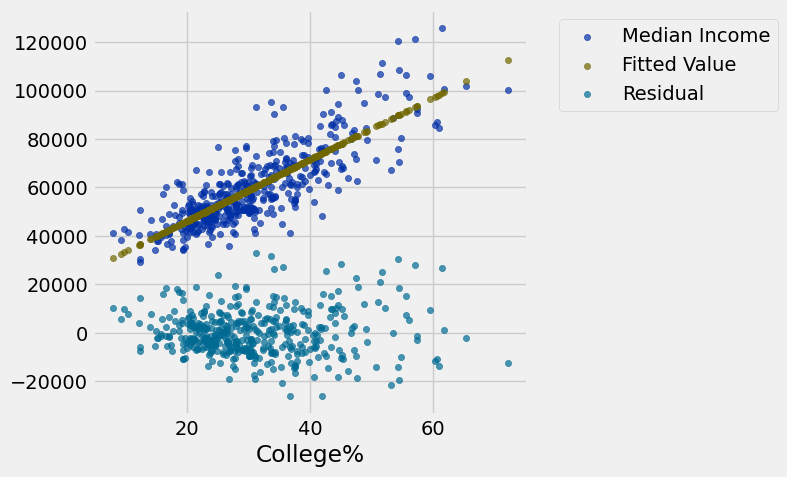

In [16]:
demographics.scatter('College%')

In [118]:
def plot_residuals(t, x, y):
    tbl = t.with_columns(
        'Fitted', fitted_values(t, x, y),
        'Residual', residuals(t, x, y)
    )
    tbl.select(x, y, 'Fitted').scatter(0)
    tbl.scatter(x, 'Residual')

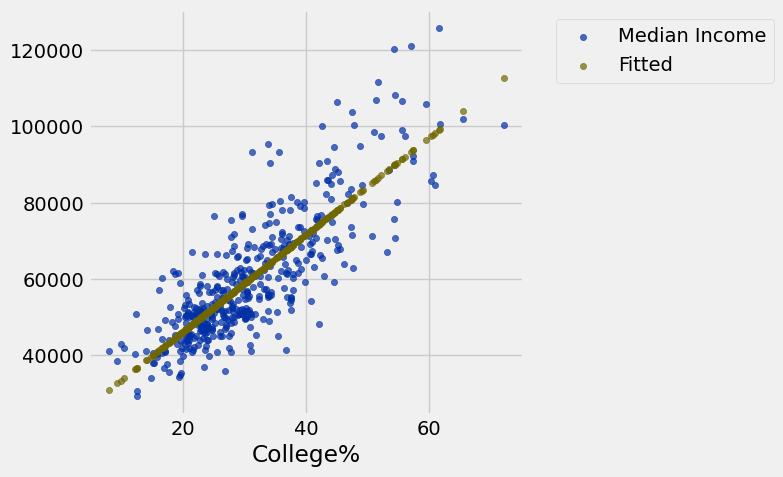

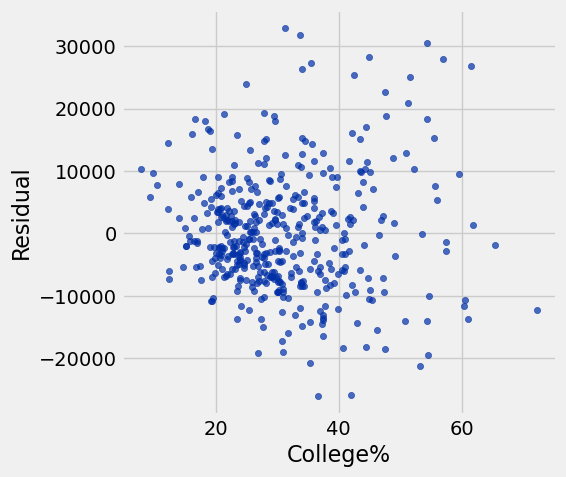

In [119]:
plot_residuals(demographics, 'College%', 'Median Income')

In [85]:
def fitted_values(t, x, y):
    """Return an array of the regressions estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

In [86]:
demographics = demographics.with_columns(
    'Fitted Value', fitted_values(demographics, 'College%', 'Median Income'),
    'Residual', residuals(demographics, 'College%', 'Median Income')
)
demographics

Median Income,College%,Fitted Value,Residual
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


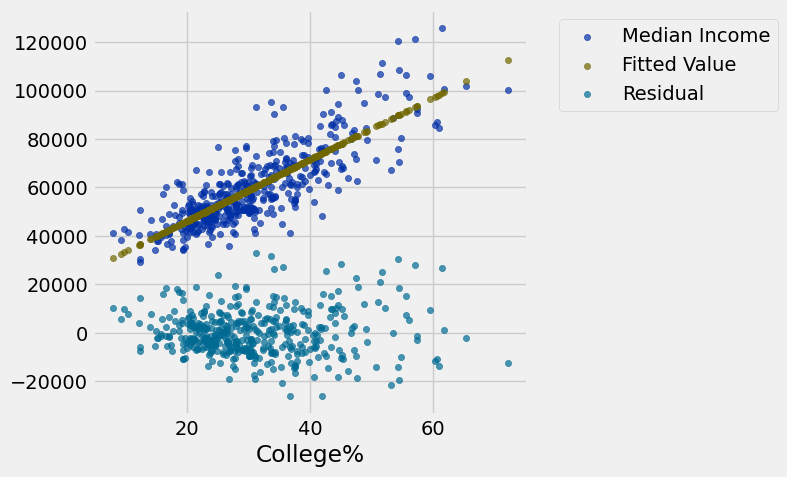

In [19]:
demographics.scatter('College%')

In [87]:
correlation(demographics, 'College%', 'Median Income')

0.81846485171413352

In [88]:
regression_slope = slope(demographics, 'College%', 'Median Income')
regression_intercept = intercept(demographics, 'College%', 'Median Income')
regression_slope, regression_intercept

(1270.70168946388, 20802.577766677925)

In [89]:
def plot_residuals(t, x, y):
    tbl = t.with_columns(
        'Fitted', fitted_values(t, x, y),
        'Residual', residuals(t, x, y)
    )
    tbl.select(x, y, 'Fitted').scatter(0)
    tbl.scatter(x, 'Residual')

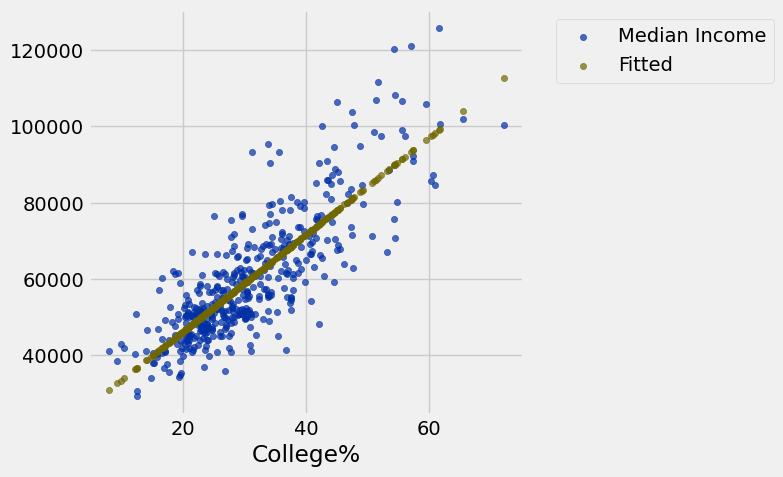

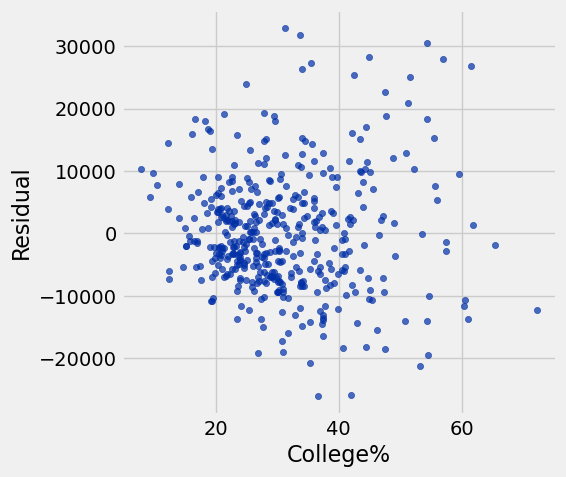

In [90]:
plot_residuals(demographics, 'College%', 'Median Income')

---

### Demo: More Residuals

Visualize the residuals associated with the `family_heights.csv` data set when predicting `Child` values from `Midparent` values using linear regression.

In [99]:
def residual(table, x, y):
    return table.column(y) - fitted_values(table, x, y)

In [102]:
def residual_plot(table, x, y):
    x_array = table.column(x)
    t = Table().with_columns(
            x, x_array,
            'residuals', residual(table, x, y)
        )
    t.scatter(x, 'residuals', color='r')
    xlims = make_array(min(x_array), max(x_array))
    plt.plot(xlims, make_array(0, 0), color='darkblue', lw=4)
    plt.title('Residual Plot')

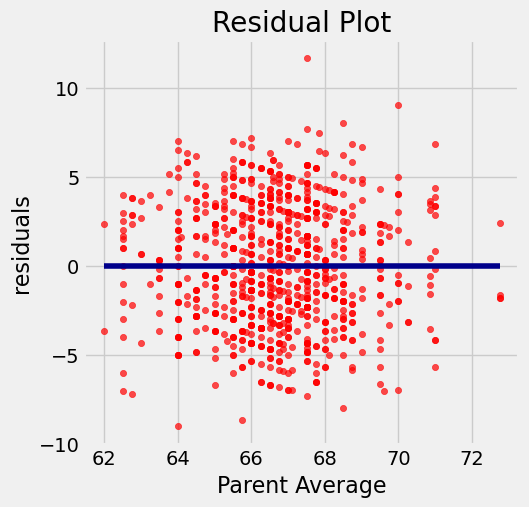

In [103]:
family_heights = Table.read_table('family_heights.csv')
parents = (family_heights.column('father') + family_heights.column('mother'))/2
heights = Table().with_columns(
    'Parent Average', parents,
    'Child', family_heights.column('child')
    )
residual_plot(heights, 'Parent Average', 'Child')

### Dugongs

In [120]:
dugong = Table.read_table('dugong.csv')
dugong.show(5)

Length,Age
1.8,1
1.85,1.5
1.87,1.5
1.77,1.5
2.02,2.5


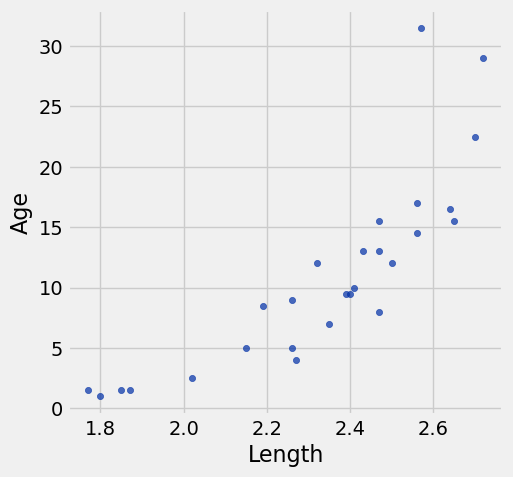

In [121]:
dugong.scatter('Length', 'Age')

In [122]:
correlation(dugong, 'Length', 'Age')

0.82964745549057139

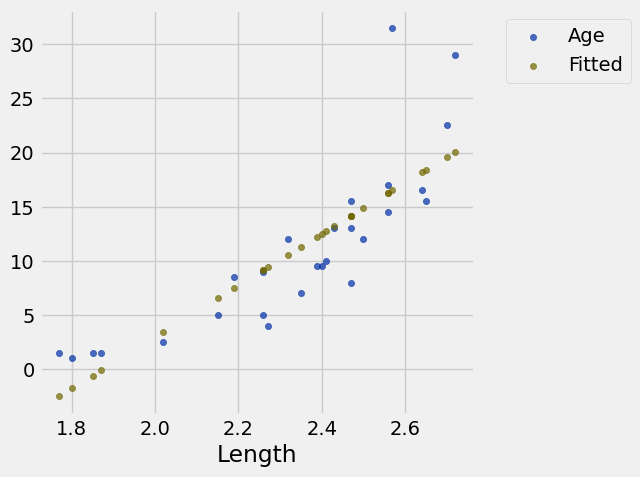

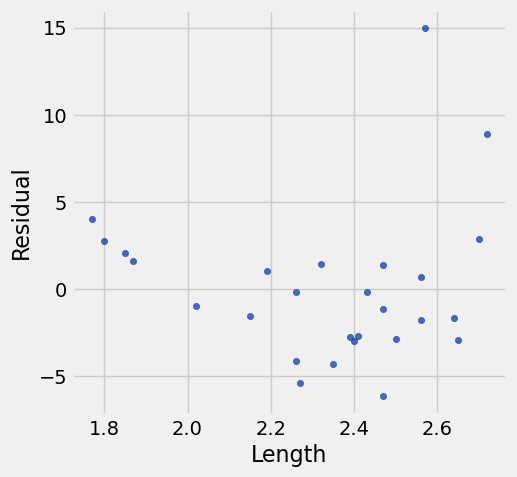

In [123]:
plot_residuals(dugong, 'Length', 'Age')

### Examples: Scatter Plots from Residual Plots

* Generate some example data.
* Inspect residual plots with the goal of trying to visualize the related scatter plots.

*Note:* We do not cover `np.linspace` and `np.random.normal` in this course, so you are not expected to understand that part of the following code. We are just using those functions to conveniently create example data.

In [104]:
np.random.seed(2024) # For reproducibility

x1 = np.linspace(0, 10, 100)
x2 = np.linspace(-5, 5, 100)
x3 = np.linspace(0, 10, 100)

examples = Table().with_columns(
    'x1', x1,
    'y1', 2 * x1 + 1 + np.random.normal(0, 1, len(x1)),
    'x2', x2,
    'y2', 0.5 * x2**2 + 2 * x2 + 1 + np.random.normal(0, 1, len(x2)),
    'x3', x3, 
    'y3', 2 * x3 + 1 + np.random.normal(0, 0.5 * x3, len(x3)),
)
examples = examples.with_columns(
    'residuals1', residuals(examples, 'x1', 'y1'),
    'residuals2', residuals(examples, 'x2', 'y2'),
    'residuals3', residuals(examples, 'x3', 'y3'),
)
examples

x1,y1,x2,y2,x3,y3,residuals1,residuals2,residuals3
0,2.66805,-5,3.58722,0,1,1.57743,8.286,-0.757601
0.10101,1.93937,-4.89899,3.30594,0.10101,1.30834,0.647955,7.80201,-0.618114
0.20202,1.2025,-4.79798,3.60429,0.20202,1.37656,-0.289704,7.89765,-0.718749
0.30303,1.45515,-4.69697,3.10742,0.30303,1.65453,-0.237852,7.19807,-0.609631
0.40404,2.72413,-4.59596,0.758999,0.40404,1.72197,0.830338,4.64694,-0.711049
0.505051,3.17043,-4.49495,3.24055,0.505051,2.26178,1.07584,6.92579,-0.3401
0.606061,-0.407841,-4.39394,1.16053,0.606061,2.54223,-2.70322,4.64305,-0.228504
0.707071,1.08885,-4.29293,-0.00340429,0.707071,1.23665,-1.40733,3.27641,-1.70294
0.808081,3.07615,-4.19192,1.80354,0.808081,2.82432,0.37918,4.88064,-0.284124
0.909091,2.92023,-4.09091,1.04097,0.909091,2.36869,0.0224699,3.91537,-0.908606


#### Example 1

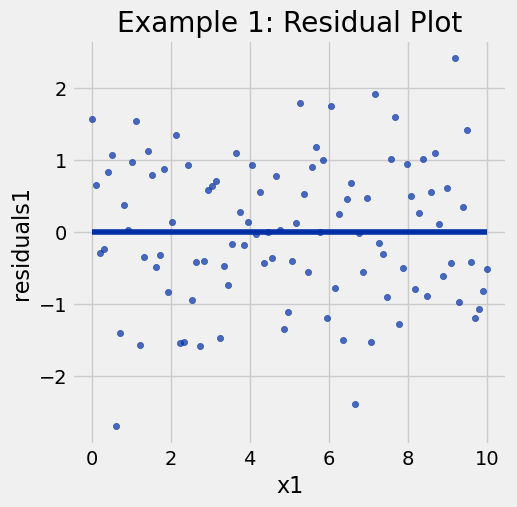

In [105]:
examples.scatter('x1', 'residuals1', fit_line=True)
plt.title('Example 1: Residual Plot')
plt.show()

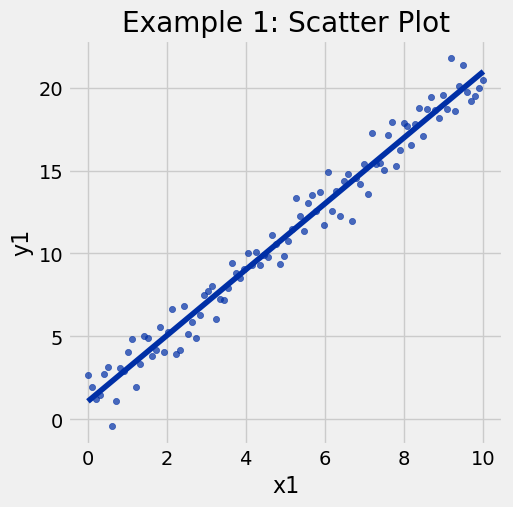

In [106]:
examples.scatter('x1', 'y1', fit_line=True)
plt.title('Example 1: Scatter Plot')
plt.show()

#### Example 2

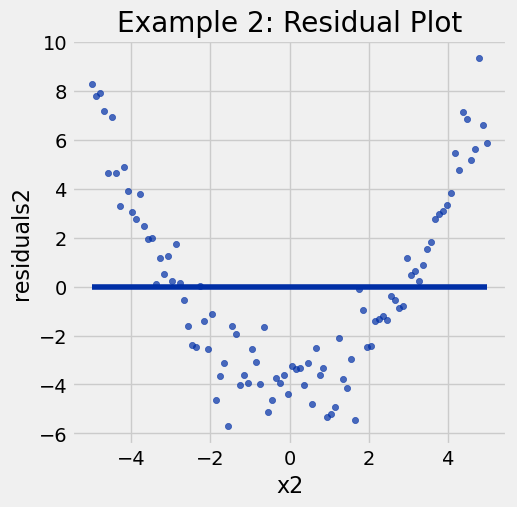

In [107]:
examples.scatter('x2', 'residuals2', fit_line=True)
plt.title('Example 2: Residual Plot')
plt.show()

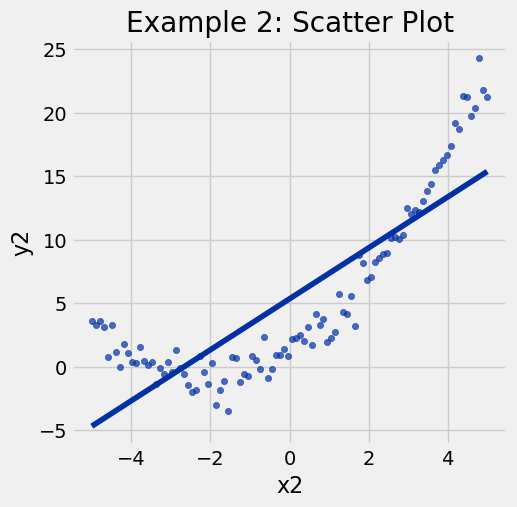

In [108]:
examples.scatter('x2', 'y2', fit_line=True)
plt.title('Example 2: Scatter Plot')
plt.show()

#### Example 3

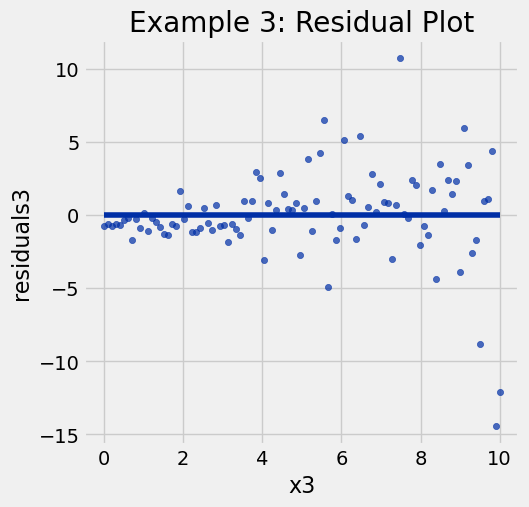

In [109]:
examples.scatter('x3', 'residuals3', fit_line=True)
plt.title('Example 3: Residual Plot')
plt.show()

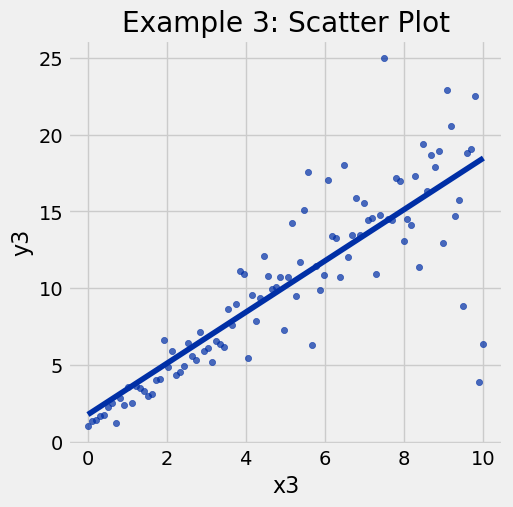

In [110]:
examples.scatter('x3', 'y3', fit_line=True)
plt.title('Example 3: Scatter Plot')
plt.show()

---

### Example: Blood Pressure

* A person's blood pressure reading consists of two numbers:
    * Systolic pressure (the top number) reflects the force produced by the heart when it pumps blood out to the body
    * Diastolic blood pressure (the bottom number) is the pressure in your blood vessels when the heart is at rest
* According to [Harvard Health](https://www.health.harvard.edu/staying-healthy/which-blood-pressure-number-is-important#:~:text=Over%20the%20years%2C%20research%20has,compared%20with%20elevated%20diastolic%20pressures.):
> Over the years, research has found that both numbers are equally important in monitoring heart health. However, most studies show a greater risk of stroke and heart disease related to higher systolic pressures compared with elevated diastolic pressures. That's especially true in people ages 50 and older, which is why doctors tend to monitor the top number more closely.



### Demo: US Blood Pressure

* Load recent blood pressure data from US residents (18+) according to the [most recent NHANES data](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023).
* Examine the residuals associated with average systolic pressure over the ages.
* Determine if linear regression is a good choice for a prediction model in this case.

In [59]:
blood_pressure = Table.read_table('blood_pressure.csv')
blood_pressure

Age,Average Systolic average,Average Diastolic average
18,111.425,66.6425
19,109.872,67.7528
20,112.451,69.4379
21,111.262,68.3077
22,109.915,70.1273
23,111.902,71.0874
24,111.632,69.3793
25,111.354,70.2487
26,111.567,71.3743
27,112.363,71.3873


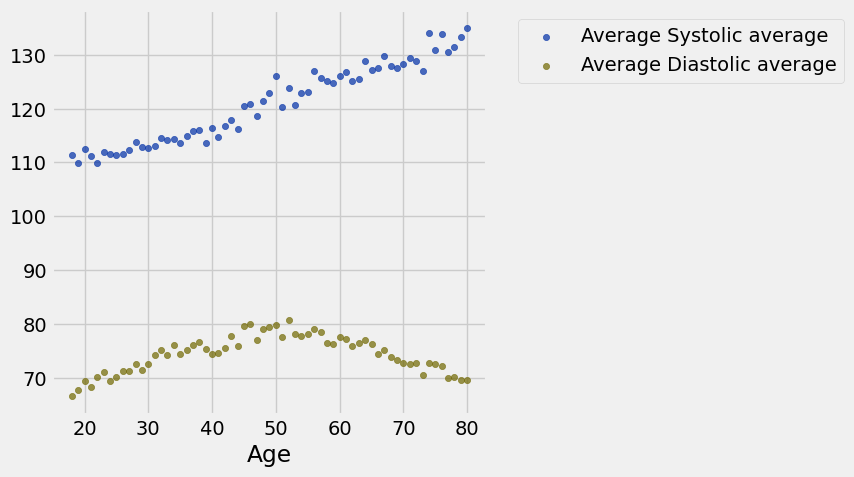

In [60]:
blood_pressure.scatter('Age')

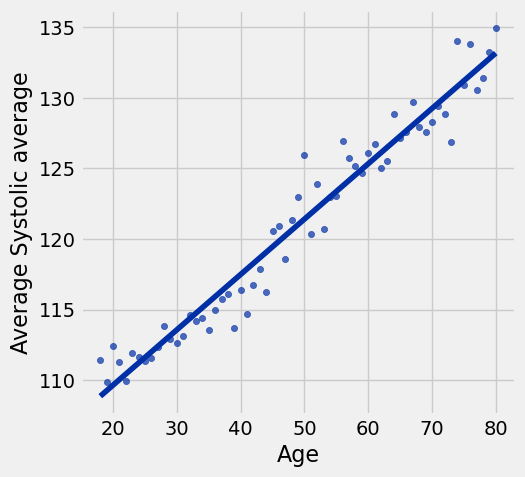

In [61]:
blood_pressure.scatter('Age', 'Average Systolic average', fit_line=True)

_Be careful of the ecological correlation issue we have talked about previously._

---

### Residual Plot

A scatter diagram of residuals
* Should look like an unassociated blob for linear relations
* But will show patterns for non-linear relations
* Used to check whether linear regression is appropriate
* Look for curves, trends, changes in spread, outliers, or any other patterns


---

### Properties of Residuals

Residuals from a linear regression always have
* Zero mean (so rmse = SD of residuals)
* Zero correlation with $x$
* Zero correlation with the fitted values

### Average of Residuals

In [125]:
round(np.average(residuals(dugong, 'Length', 'Age')), 6)

0.0

In [ ]:
round(np.average(residuals(heights, 'MidParent', 'Child')), 6)

In [ ]:
round(np.average(residuals(demographics, 'College%', 'Median Income')), 6)

In [ ]:
heights = heights.with_columns(
    'Residual', residuals(heights, 'MidParent', 'Child'),
    'Fitted Value', fitted_values(heights, 'MidParent', 'Child')
)

In [ ]:
round(correlation(heights, 'MidParent', 'Residual'), 6)

In [ ]:
round(correlation(heights, 'Fitted Value', 'Residual'), 6)

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>